# L01 · Basic Statistics and Introduction to R (in Python)

*Companion notebook to **Section 1.1 (Lecture 1)** of the LaTeX notes (`latex/main.pdf`). Run the cells top to bottom.*

In [1]:
# --- Setup: imports, fixed seed, and a relative path to the data/ folder ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

rng = np.random.default_rng(2024)          # fixed seed for reproducibility
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
sns.set_theme(style="whitegrid")

# Find the project's data/ folder by walking up from the notebook's folder.
DATA = next(p / "data" for p in [Path.cwd(), *Path.cwd().parents] if (p / "data").is_dir())
print("data folder:", DATA)

data folder: /home/claude/LSM/data


## Theory recap
For data $x_1,\dots,x_n$:

* **Centre** — mean $\bar x=\frac1n\sum x_i$, median, mode.
* **Spread** — sample variance $s^2=\frac{1}{n-1}\sum (x_i-\bar x)^2$, standard deviation $s$, $\mathrm{IQR}=Q_3-Q_1$.
* **Shape** — symmetric or skewed.

Key identity: $\sum (x_i-c)^2 = \sum (x_i-\bar x)^2 + n(\bar x - c)^2$, so the mean is the *least-squares constant*.

## Example 1.x — summaries by hand, checked in code

In [2]:
x = np.array([3, 7, 8, 5, 12, 14, 21, 13, 18])
print("sorted  :", np.sort(x))
print("mean    :", x.mean())                 # 101/9 = 11.2222
print("median  :", np.median(x))             # 12
print("var(s^2):", x.var(ddof=1))            # 287.5556/8 = 35.9444  (ddof=1 matches R's var)
print("sd      :", x.std(ddof=1))            # 5.9954
q1, q3 = np.percentile(x, [25, 75])          # NumPy's default = R's type 7
print("Q1, Q3, IQR:", q1, q3, q3 - q1)       # 7, 14, 7

sorted  : [ 3  5  7  8 12 13 14 18 21]
mean    : 11.222222222222221
median  : 12.0
var(s^2): 35.94444444444444
sd      : 5.995368582868316
Q1, Q3, IQR: 7.0 14.0 7.0


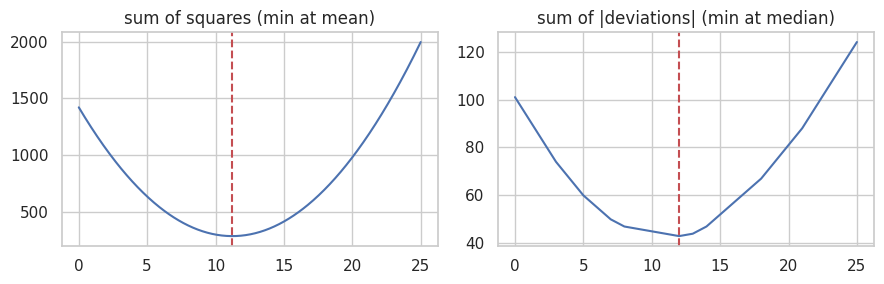

argmin of squares: 11.200000000000001   argmin of abs: 12.0


In [3]:
# The mean minimises c -> sum (x_i - c)^2 ; the median minimises c -> sum |x_i - c|
cs = np.linspace(0, 25, 501)
sq = [((x - c) ** 2).sum() for c in cs]
ab = [np.abs(x - c).sum() for c in cs]
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].plot(cs, sq); ax[0].axvline(x.mean(), ls="--", color="r"); ax[0].set_title("sum of squares (min at mean)")
ax[1].plot(cs, ab); ax[1].axvline(np.median(x), ls="--", color="r"); ax[1].set_title("sum of |deviations| (min at median)")
plt.tight_layout(); plt.show()
print("argmin of squares:", cs[np.argmin(sq)], "  argmin of abs:", cs[np.argmin(ab)])

## The `airquality` data frame
R: `head(airquality)`, `tail(airquality)`, `airquality[148,4]`, `airquality$Temp[148]`, `airquality[,c(1,4)]`.

In [4]:
aq = pd.read_csv(DATA / "airquality.csv")
print(aq.shape)            # 153 rows, 6 columns
aq.head(10)

(153, 6)


,Ozone,Solar.R,Wind,Temp,Month,Day
0,41.0,190.0,7.4,67,5,1
1,36.0,118.0,8.0,72,5,2
2,12.0,149.0,12.6,74,5,3
3,18.0,313.0,11.5,62,5,4
4,NaN,NaN,14.3,56,5,5
5,28.0,NaN,14.9,66,5,6
6,23.0,299.0,8.6,65,5,7
7,19.0,99.0,13.8,59,5,8
8,8.0,19.0,20.1,61,5,9
9,NaN,194.0,8.6,69,5,10


In [5]:
print(aq.tail())
print("aq.iloc[147, 3] =", aq.iloc[147, 3])        # R's airquality[148,4] -> 63 (Python counts from 0)
print("aq.Temp[147]    =", aq.Temp[147])
print(aq.iloc[147])                                # the whole 148th row
aq.iloc[:, [0, 3]].head()                          # Ozone and Temp columns

     Ozone  Solar.R  Wind  Temp  Month  Day
148   30.0    193.0   6.9    70      9   26
149    NaN    145.0  13.2    77      9   27
150   14.0    191.0  14.3    75      9   28
151   18.0    131.0   8.0    76      9   29
152   20.0    223.0  11.5    68      9   30
aq.iloc[147, 3] = 63
aq.Temp[147]    = 63
Ozone      14.0
Solar.R    20.0
Wind       16.6
Temp       63.0
Month       9.0
Day        25.0
Name: 147, dtype: float64


,Ozone,Temp
0,41.0,67
1,36.0,72
2,12.0,74
3,18.0,62
4,NaN,56


In [6]:
# summary(airquality$Temp): Min 56, Q1 72, Median 79, Mean 77.88, Q3 85, Max 97
aq.Temp.describe()

count    153.0000
mean      77.8824
std        9.4653
min       56.0000
25%       72.0000
50%       79.0000
75%       85.0000
max       97.0000
Name: Temp, dtype: float64

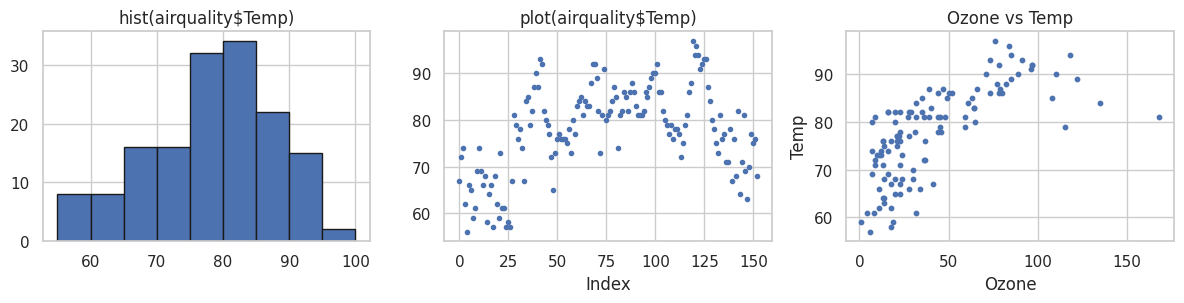

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.2))
ax[0].hist(aq.Temp, bins=np.arange(55, 101, 5), edgecolor="k"); ax[0].set_title("hist(airquality$Temp)")
ax[1].plot(aq.Temp.values, "o", ms=3); ax[1].set(title="plot(airquality$Temp)", xlabel="Index")
ax[2].scatter(aq.Ozone, aq.Temp, s=10); ax[2].set(title="Ozone vs Temp", xlabel="Ozone", ylabel="Temp")
plt.tight_layout(); plt.show()

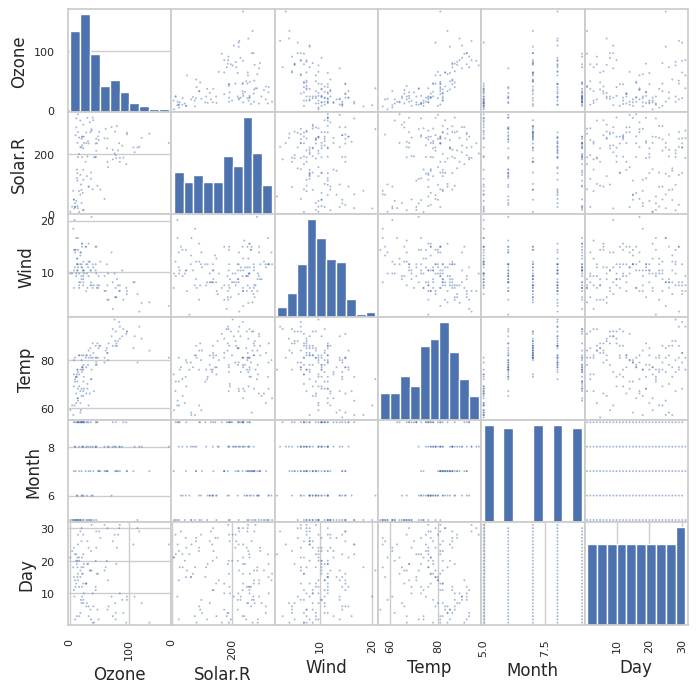

In [8]:
# plot(airquality): all pairwise scatter plots
pd.plotting.scatter_matrix(aq, figsize=(8, 8), s=8)
plt.show()

In [9]:
# Chebyshev check: proportion of Temp within 3 population-SDs of the mean (must be >= 8/9)
sig = aq.Temp.std(ddof=0)
print("within 2 sd:", np.mean(np.abs(aq.Temp - aq.Temp.mean()) < 2 * sig))
print("within 3 sd:", np.mean(np.abs(aq.Temp - aq.Temp.mean()) < 3 * sig))

within 2 sd: 0.9411764705882353
within 3 sd: 1.0


## Try it yourself
1. Compute the summaries of Exercise 1 (`2,4,4,5,7,9,11`) and check your hand answers.
2. `aq.groupby("Month").Temp.mean()` — which month is hottest? (Exercise 4.)
3. How many `Ozone` values are missing? (`aq.Ozone.isna().sum()`) How does `describe()` treat them?